# 2.1 — Vectors, at the computer

Do the **pen-and-paper worksheet first**. Here you'll *see* both views of a vector —
arrow and list — and meet the numpy array, the object every piece of ML code is made of.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt
from plots import axes_through_origin

# A tiny helper we'll reuse all module: draw a vector as an arrow.
def arrow(ax, v, color="C0", label=None, start=(0, 0)):
    ax.quiver(start[0], start[1], v[0], v[1],           # from start, go v across/up
              angles="xy", scale_units="xy", scale=1,   # "draw it true to the grid"
              color=color, width=0.012)
    if label:
        ax.annotate(label, (start[0] + v[0], start[1] + v[1]),
                    textcoords="offset points", xytext=(6, 6), color=color, fontsize=12)

## 1. View one: arrows

A vector $(3, 4)$ is an instruction: *from the origin, go 3 across and 4 up.*

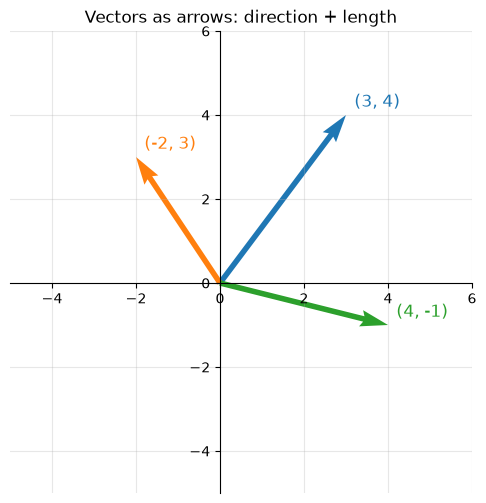

In [2]:
ax = axes_through_origin(xlim=(-5, 6), ylim=(-5, 6))
arrow(ax, [3, 4],  "C0", "(3, 4)")
arrow(ax, [-2, 3], "C1", "(-2, 3)")
arrow(ax, [4, -1], "C2", "(4, -1)")
ax.set_title("Vectors as arrows: direction + length")
plt.show()

## 2. View two: lists — the numpy array

Same objects, as the machine sees them. Three bits of syntax to own for life:
`np.array`, indexing with `[ ]` (counting from **0**), and `.shape`.

In [3]:
v = np.array([3, 4])          # the vector (3, 4) as a numpy array

print("v        =", v)
print("v[0]     =", v[0], "   <- FIRST component: Python counts from 0")
print("v[1]     =", v[1])
print("v.shape  =", v.shape, "  <- '2 components'. You'll check .shape constantly in ML")
print("length   =", np.linalg.norm(v), " <- magnitude: square, add, root — Pythagoras")

# The classic trap: a Python LIST is not an ARRAY.
print("\nlist  [3, 4] + [1, 1] =", [3, 4] + [1, 1], "   <- lists glue together!")
print("array [3, 4] + [1, 1] =", np.array([3, 4]) + np.array([1, 1]), "        <- arrays do math")

v        = [3 4]
v[0]     = 3    <- FIRST component: Python counts from 0
v[1]     = 4
v.shape  = (2,)   <- '2 components'. You'll check .shape constantly in ML
length   = 5.0  <- magnitude: square, add, root — Pythagoras

list  [3, 4] + [1, 1] = [3, 4, 1, 1]    <- lists glue together!
array [3, 4] + [1, 1] = [4 5]         <- arrays do math


## 3. Data points ARE vectors

Describe streaming users by `(hours of sci-fi, hours of comedy)` per month.
Each user becomes an arrow in "taste space" — and suddenly geometry means something:
users pointing the same way have the same taste.

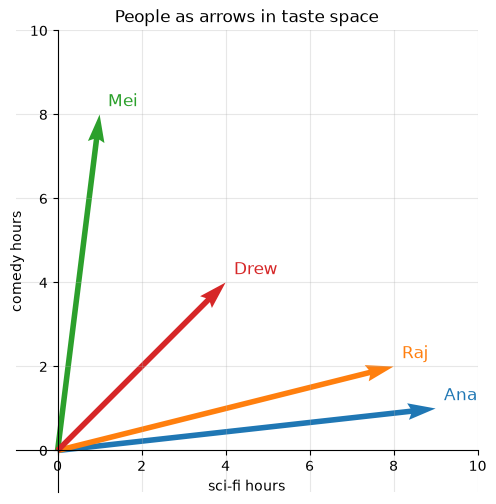

In [4]:
users = {
    "Ana":  np.array([9, 1]),    # sci-fi devotee
    "Raj":  np.array([8, 2]),    # kindred spirit
    "Mei":  np.array([1, 8]),    # comedy person
    "Drew": np.array([4, 4]),    # bit of both
}

ax = axes_through_origin(xlim=(-1, 10), ylim=(-1, 10))
for i, (name, vec) in enumerate(users.items()):   # loop over the dictionary's name/vector pairs
    arrow(ax, vec, f"C{i}", name)
ax.set_xlabel("sci-fi hours")
ax.set_ylabel("comedy hours")
ax.set_title("People as arrows in taste space")
plt.show()
# Ana and Raj point almost the same way. Lesson 2.3 turns 'almost the same way' into a number.

In [5]:
# YOUR TURN
# 1) Check your worksheet Part B magnitudes — one is set up, do b and c yourself:
print(np.linalg.norm(np.array([6, 8])))       # worksheet 4a — should match your hand answer

# 2) Worksheet Part D: your unit vector for (6, 8). Its norm should print 1.0:
# u = np.array([?, ?])
# print(np.linalg.norm(u))

# 3) Add YOURSELF to taste space: your_vec = np.array([?, ?]) — then re-run the cell above
#    with your entry added to the users dictionary. Whose arrow is closest to yours?

10.0


## 4. 🌀 The deep end you're heading for

Your taste-space used 2 numbers per person. GPT-class models describe every *word* with
**thousands** of numbers — arrows in a space you can't draw but can compute in perfectly.
In that space, `cat` and `kitten` point almost the same way; `cat` and `carburettor` don't.

Everything you just did — build the arrow, measure it, compare directions — works *unchanged*
up there. That's the secret of this whole module: **learn it in 2-D, run it in 768-D.**

---
*Done? Photograph your worksheet into `scans/inbox/` and tell Claude. Next: 2.2 — vector arithmetic,
where `king − man + woman ≈ queen` stops being a slogan.*